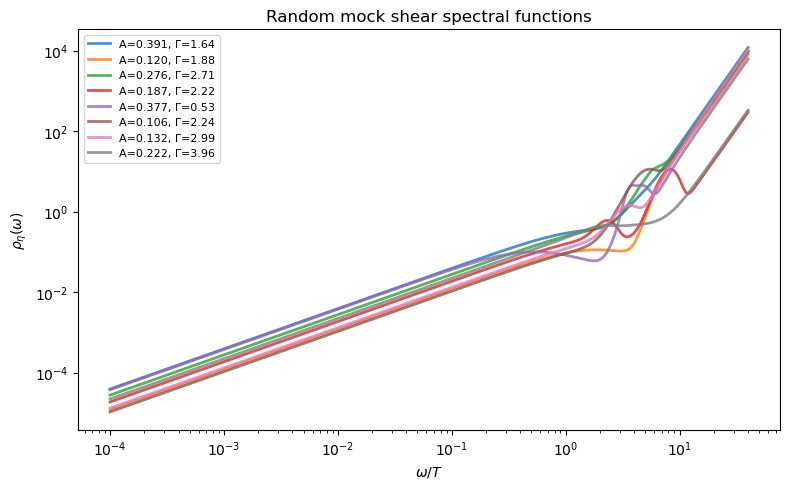

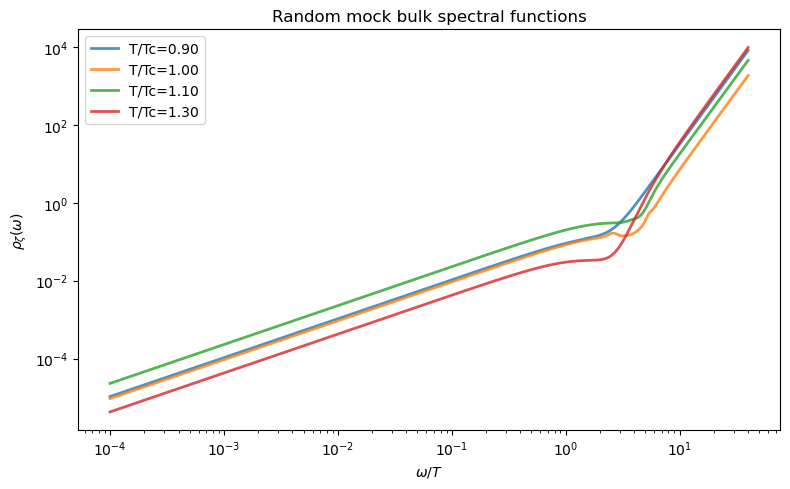

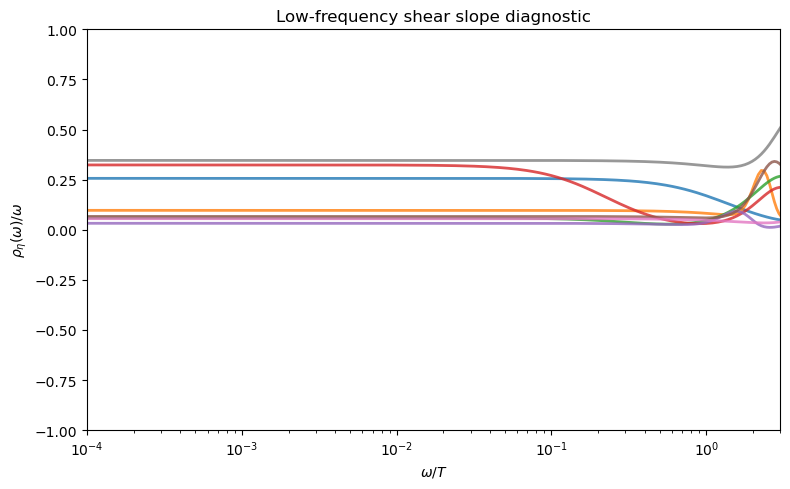

eta =  [1.229, 0.378, 0.869, 0.587, 1.185, 0.333, 0.413, 0.697]
zeta =  [0.331, 0.294, 0.72, 0.134]


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
from typing import Optional, Dict, Tuple


# ============================================================
# 1. Utilities
# ============================================================

def make_frequency_grid(
    wmin=1e-4,
    wsplit=1.0,
    wmax=40.0,
    nlog=200,
    nlin=400
):
    """
    Build a mixed log-linear frequency grid in units of T:
        x = omega / T

    Returns
    -------
    w : np.ndarray
        Frequency grid
    """
    w_log = np.logspace(np.log10(wmin), np.log10(wsplit), nlog, endpoint=False)
    w_lin = np.linspace(wsplit, wmax, nlin)
    w = np.unique(np.concatenate([w_log, w_lin]))
    return w


def smooth_switch(w, Lambda=3.0, sharpness=4.0):
    """
    Smoothly turn on the UV contribution around Lambda.

    f(w) ~ 0 for w << Lambda
    f(w) ~ 1 for w >> Lambda
    """
    x = (w / Lambda) ** sharpness
    return x / (1.0 + x)


def gaussian_bump(w, amp, mu, sigma, power=1):
    """
    A flexible bump term:
        amp * w^power * exp(-(w-mu)^2 / (2 sigma^2))
    """
    return amp * (w ** power) * np.exp(-0.5 * ((w - mu) / sigma) ** 2)


def lorentzian_transport_peak(w, A, Gamma):
    """
    IR transport peak:
        rho_IR(w) = A * w / (1 + (w/Gamma)^2)

    Low-frequency slope:
        rho(w)/w -> A as w -> 0
    So viscosity is proportional to A.
    """
    return A * w / (1.0 + (w / Gamma) ** 2)


# ============================================================
# 2. Parameter containers
# ============================================================

@dataclass
class ShearParams:
    A: float               # IR slope coefficient
    Gamma: float           # transport width
    B: float               # UV amplitude
    Lambda_uv: float       # UV onset scale
    sharpness_uv: float    # UV switch sharpness
    n_bumps: int = 0       # number of mid-frequency bumps
    bump_amps: Optional[np.ndarray] = None
    bump_mus: Optional[np.ndarray] = None
    bump_sigmas: Optional[np.ndarray] = None


@dataclass
class BulkParams:
    A: float
    Gamma: float
    D: float
    Lambda_uv: float
    sharpness_uv: float
    n_bumps: int = 0
    bump_amps: Optional[np.ndarray] = None
    bump_mus: Optional[np.ndarray] = None
    bump_sigmas: Optional[np.ndarray] = None
    Tc: float = 1.0
    T: float = 1.0


# ============================================================
# 3. Spectral function models
# ============================================================

def rho_shear(w, params: ShearParams):
    """
    Mock shear spectral function in dimensionless units x = omega/T.

    Structure:
        rho = IR transport + UV tail + optional mid-frequency bumps

    Here we use a simple UV tail ~ w^4 * switch(w).
    """
    # IR transport
    rho_ir = lorentzian_transport_peak(w, params.A, params.Gamma)

    # UV tail
    uv_switch = smooth_switch(w, Lambda=params.Lambda_uv, sharpness=params.sharpness_uv)
    rho_uv = params.B * (w ** 4) * uv_switch

    # Mid-frequency structure
    rho_mid = np.zeros_like(w)
    if params.n_bumps > 0:
        for amp, mu, sigma in zip(params.bump_amps, params.bump_mus, params.bump_sigmas):
            rho_mid += gaussian_bump(w, amp=amp, mu=mu, sigma=sigma, power=3)

    rho = rho_ir + rho_mid + rho_uv

    # Safety
    rho = np.maximum(rho, 0.0)
    return rho


def bulk_peak_enhancement(T, Tc=1.0, height=1.0, width=0.12):
    """
    Temperature-dependent enhancement factor for bulk near Tc.
    """
    return 1.0 + height * np.exp(-0.5 * ((T - Tc) / width) ** 2)


def rho_bulk(w, params: BulkParams, peak_height=2.0, peak_width=0.12):
    """
    Mock bulk spectral function.

    Similar to shear, but the IR coefficient A is enhanced near T ~ Tc.
    """
    enh = bulk_peak_enhancement(
        T=params.T, Tc=params.Tc, height=peak_height, width=peak_width
    )

    A_eff = params.A * enh

    rho_ir = lorentzian_transport_peak(w, A_eff, params.Gamma)

    uv_switch = smooth_switch(w, Lambda=params.Lambda_uv, sharpness=params.sharpness_uv)
    rho_uv = params.D * (w ** 4) * uv_switch

    rho_mid = np.zeros_like(w)
    if params.n_bumps > 0:
        for amp, mu, sigma in zip(params.bump_amps, params.bump_mus, params.bump_sigmas):
            # bulk bumps can be softer than shear
            rho_mid += gaussian_bump(w, amp=amp, mu=mu, sigma=sigma, power=1)

    rho = rho_ir + rho_mid + rho_uv
    rho = np.maximum(rho, 0.0)
    return rho


# ============================================================
# 4. Random parameter generators
# ============================================================

def sample_shear_params(rng=np.random.default_rng()) -> ShearParams:
    """
    Randomly sample physically plausible mock shear spectral parameters.
    All frequencies are in units of T.
    """
    A = rng.uniform(0.02, 0.4)          # controls viscosity
    Gamma = rng.uniform(0.2, 4.0)       # transport width
    B = rng.uniform(1e-4, 5e-3)         # UV amplitude
    Lambda_uv = rng.uniform(2.0, 6.0)
    sharpness_uv = rng.uniform(2.0, 8.0)

    n_bumps = rng.integers(0, 3)        # 0, 1, or 2 bumps

    if n_bumps > 0:
        bump_amps = rng.uniform(1e-3, 5e-2, size=n_bumps)
        bump_mus = rng.uniform(1.0, 8.0, size=n_bumps)
        bump_sigmas = rng.uniform(0.2, 1.5, size=n_bumps)
    else:
        bump_amps = np.array([])
        bump_mus = np.array([])
        bump_sigmas = np.array([])

    return ShearParams(
        A=A,
        Gamma=Gamma,
        B=B,
        Lambda_uv=Lambda_uv,
        sharpness_uv=sharpness_uv,
        n_bumps=n_bumps,
        bump_amps=bump_amps,
        bump_mus=bump_mus,
        bump_sigmas=bump_sigmas
    )


def sample_bulk_params(T=1.0, Tc=1.0, rng=np.random.default_rng()) -> BulkParams:
    """
    Randomly sample mock bulk spectral parameters.
    Bulk is usually harder and can vary more strongly near Tc.
    """
    A = rng.uniform(0.005, 0.2)
    Gamma = rng.uniform(0.1, 3.0)
    D = rng.uniform(5e-5, 5e-3)
    Lambda_uv = rng.uniform(2.0, 6.0)
    sharpness_uv = rng.uniform(2.0, 8.0)

    n_bumps = rng.integers(0, 3)

    if n_bumps > 0:
        bump_amps = rng.uniform(1e-3, 5e-2, size=n_bumps)
        bump_mus = rng.uniform(0.5, 6.0, size=n_bumps)
        bump_sigmas = rng.uniform(0.2, 1.2, size=n_bumps)
    else:
        bump_amps = np.array([])
        bump_mus = np.array([])
        bump_sigmas = np.array([])

    return BulkParams(
        A=A,
        Gamma=Gamma,
        D=D,
        Lambda_uv=Lambda_uv,
        sharpness_uv=sharpness_uv,
        n_bumps=n_bumps,
        bump_amps=bump_amps,
        bump_mus=bump_mus,
        bump_sigmas=bump_sigmas,
        Tc=Tc,
        T=T
    )


# ============================================================
# 5. Convenience wrappers
# ============================================================

def generate_random_shear_spectrum(w, rng=np.random.default_rng()):
    params = sample_shear_params(rng)
    rho = rho_shear(w, params)
    return rho, params


def generate_random_bulk_spectrum(w, T=1.0, Tc=1.0, rng=np.random.default_rng()):
    params = sample_bulk_params(T=T, Tc=Tc, rng=rng)
    rho = rho_bulk(w, params)
    return rho, params

def extract_mock_viscosity_from_params_shear(params, prefactor=np.pi):
    return prefactor * params.A

def extract_mock_viscosity_from_params_bulk(params, peak_height=2.0, peak_width=0.12, prefactor=np.pi):
    enh = bulk_peak_enhancement(params.T, params.Tc, height=peak_height, width=peak_width)
    return prefactor * params.A * enh


# ============================================================
# 6. Example usage / plotting
# ============================================================

if __name__ == "__main__":
    rng = np.random.default_rng(1234)


    # Frequency grid x = omega/T
    w = make_frequency_grid()
    w

    # ----- Shear examples -----
    plt.figure(figsize=(8, 5))
    Eta = []
    for _ in range(8):
        rho, params = generate_random_shear_spectrum(w, rng=rng)
        eta = extract_mock_viscosity_from_params_shear(params)
        plt.loglog(w, rho, lw=2, alpha=0.8, label=f"A={params.A:.3f}, Γ={params.Gamma:.2f}")
        Eta.append(round(eta,3))


    plt.xlabel(r"$\omega/T$")
    plt.ylabel(r"$\rho_\eta(\omega)$")
    plt.title("Random mock shear spectral functions")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # ----- Bulk examples at different temperatures -----
    plt.figure(figsize=(8, 5))
    Zeta = []
    for T in [0.9, 1.0, 1.1, 1.3]:
        rho, params = generate_random_bulk_spectrum(w, T=T, Tc=1.0, rng=rng)
        zeta = extract_mock_viscosity_from_params_bulk(params)
        zeta = round(zeta,3)
        plt.loglog(w, rho, lw=2, alpha=0.8, label=f"T/Tc={T:.2f}")
        Zeta.append(zeta)

    plt.xlabel(r"$\omega/T$")
    plt.ylabel(r"$\rho_\zeta(\omega)$")
    plt.title("Random mock bulk spectral functions")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ----- Plot rho(omega)/omega near small omega -----
    plt.figure(figsize=(8, 5))
    for _ in range(8):
        rho, params = generate_random_shear_spectrum(w, rng=rng)
        plt.semilogx(w, rho / np.maximum(w, 1e-12), lw=2, alpha=0.8)

    plt.xlim(1e-4, 3)
    plt.ylim(-1, 1)
    plt.xlabel(r"$\omega/T$")
    plt.ylabel(r"$\rho_\eta(\omega)/\omega$")
    plt.title("Low-frequency shear slope diagnostic")
    plt.tight_layout()
    plt.show()

print("eta = ", Eta)
Zeta = list(map(float, Zeta))
print("zeta = ", Zeta)

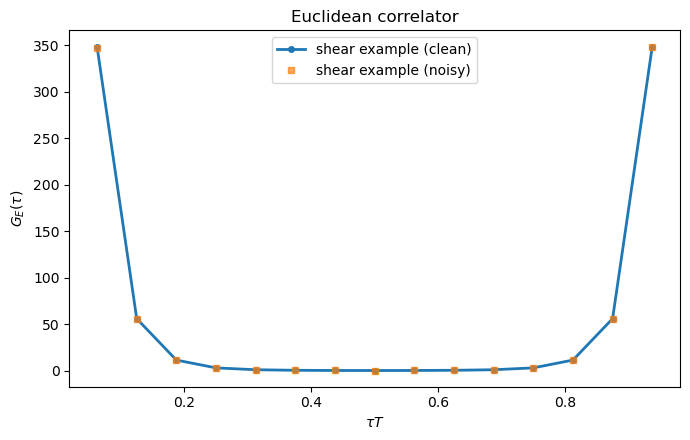

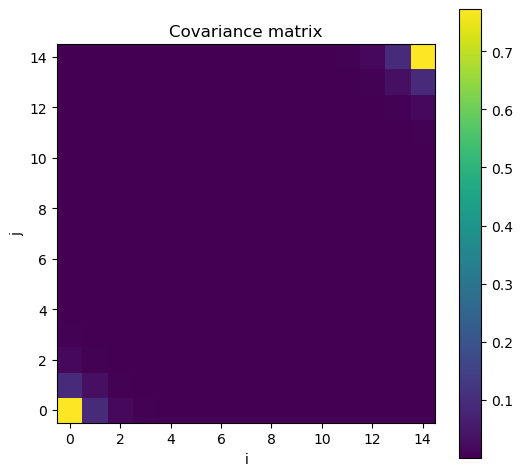

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple


# ============================================================
# 1. Euclidean time grid
# ============================================================

def make_tau_grid(Ntau: int, exclude_endpoints: bool = True):
    """
    Construct dimensionless Euclidean time grid:
        u = tau * T in (0, 1)

    Parameters
    ----------
    Ntau : int
        Number of lattice sites in Euclidean time.
    exclude_endpoints : bool
        If True, omit u=0 and u=1 to avoid contact-term issues.

    Returns
    -------
    u : np.ndarray
        Euclidean time points in units of tau*T
    """
    if exclude_endpoints:
        return np.arange(1, Ntau) / Ntau
    else:
        return np.arange(0, Ntau + 1) / Ntau


# ============================================================
# 2. Thermal kernel
# ============================================================

def thermal_kernel(u: np.ndarray, w: np.ndarray):
    """
    Stable evaluation of the Euclidean thermal kernel:
        K(u,w) = cosh[w(u-1/2)] / sinh(w/2)

    We use the numerically stable equivalent form:
        K(u,w) = (exp(-w*u) + exp(-w*(1-u))) / (1 - exp(-w))

    Parameters
    ----------
    u : np.ndarray, shape (Nu,)
        Euclidean times in units of tau*T
    w : np.ndarray, shape (Nw,)
        Frequency grid in units of omega/T

    Returns
    -------
    K : np.ndarray, shape (Nu, Nw)
        Kernel matrix
    """
    u = np.atleast_1d(u)
    w = np.atleast_1d(w)

    U = u[:, None]
    W = w[None, :]

    # Avoid division by zero at w ~ 0 using series expansion
    small = W < 1e-8
    K = np.empty((len(u), len(w)), dtype=np.float64)

    # Stable generic formula
    denom = 1.0 - np.exp(-W)
    K_generic = (np.exp(-W * U) + np.exp(-W * (1.0 - U))) / denom

    # Small-w expansion:
    # K(u,w) ~ 2/w + w * [(u-1/2)^2 - 1/12] + ...
    # The leading term is enough for numerical stability at tiny w.
    K_small = 2.0 / np.maximum(W, 1e-300)

    K[:] = np.where(small, K_small, K_generic)
    return K


# ============================================================
# 3. Numerical integration weights
# ============================================================

def trapezoidal_weights(x: np.ndarray):
    """
    Trapezoidal-rule weights for nonuniform grid.
    """
    x = np.asarray(x)
    dx = np.diff(x)

    w = np.zeros_like(x)
    w[1:-1] = 0.5 * (dx[:-1] + dx[1:])
    w[0] = 0.5 * dx[0]
    w[-1] = 0.5 * dx[-1]
    return w


# ============================================================
# 4. Correlator generation
# ============================================================

def euclidean_correlator(
    w: np.ndarray,
    rho: np.ndarray,
    u: np.ndarray,
    prefactor: float = 1.0 / (2.0 * np.pi)
):
    """
    Compute the Euclidean correlator:
        G_E(u) = ∫_0^∞ dω/(2π) rho(ω) K(u,ω)

    On the dimensionless grid x = omega/T:
        G(u) = prefactor * ∫ dx rho(x) K(u,x)

    Parameters
    ----------
    w : np.ndarray
        Frequency grid (dimensionless omega/T)
    rho : np.ndarray
        Spectral function on the same grid
    u : np.ndarray
        Euclidean time grid (dimensionless tau*T)
    prefactor : float
        Usually 1/(2π), depending on your conventions

    Returns
    -------
    G : np.ndarray
        Euclidean correlator values on u-grid
    """
    w = np.asarray(w)
    rho = np.asarray(rho)
    u = np.asarray(u)

    weights = trapezoidal_weights(w)
    K = thermal_kernel(u, w)

    # matrix-vector multiply for the integral
    G = prefactor * (K @ (rho * weights))
    return G


def build_kernel_matrix(
    u: np.ndarray,
    w: np.ndarray,
    prefactor: float = 1.0 / (2.0 * np.pi)
):
    """
    Precompute matrix M such that:
        G = M @ rho
    including integration weights.

    Useful for ML pipelines.
    """
    weights = trapezoidal_weights(w)
    K = thermal_kernel(u, w)
    M = prefactor * K * weights[None, :]
    return M


def euclidean_correlator_from_matrix(M: np.ndarray, rho: np.ndarray):
    """
    Fast correlator evaluation from precomputed kernel matrix.
    """
    return M @ rho


# ============================================================
# 5. Noise models
# ============================================================

@dataclass
class NoiseModel:
    rel_base: float = 0.002
    rel_mid: float = 0.01
    mid_width: float = 0.18
    corr_length: float = 2.0
    correlated: bool = True


def build_relative_error_profile(u: np.ndarray, noise_model: NoiseModel):
    """
    Relative error profile, usually somewhat larger near u=1/2.
    """
    return (
        noise_model.rel_base
        + noise_model.rel_mid * np.exp(-0.5 * ((u - 0.5) / noise_model.mid_width) ** 2)
    )


def build_covariance_matrix(
    G: np.ndarray,
    u: np.ndarray,
    noise_model: NoiseModel
):
    """
    Build a simple covariance matrix:
        C_ij = sigma_i sigma_j exp(-|i-j|/ell)
    """
    rel_err = build_relative_error_profile(u, noise_model)
    sigma = rel_err * np.maximum(np.abs(G), 1e-14)

    if not noise_model.correlated:
        return np.diag(sigma**2)

    idx = np.arange(len(u))
    dist = np.abs(idx[:, None] - idx[None, :])
    corr = np.exp(-dist / noise_model.corr_length)

    C = corr * np.outer(sigma, sigma)
    return C


def add_gaussian_noise(
    G: np.ndarray,
    C: np.ndarray,
    rng: Optional[np.random.Generator] = None
):
    """
    Sample noisy correlator:
        G_noisy ~ N(G, C)
    """
    if rng is None:
        rng = np.random.default_rng()

    # small jitter for numerical stability
    jitter = 1e-14 * np.eye(len(G))
    L = np.linalg.cholesky(C + jitter)
    z = rng.normal(size=len(G))
    G_noisy = G + L @ z
    return G_noisy


# ============================================================
# 6. Diagnostic plotting
# ============================================================

def plot_correlator(u, G, G_noisy=None, label=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))

    ax.plot(u, G, '-o', lw=2, ms=4, label=f'{label} (clean)' if label else 'clean')

    if G_noisy is not None:
        ax.plot(u, G_noisy, 's', ms=4, alpha=0.7, label=f'{label} (noisy)' if label else 'noisy')

    ax.set_xlabel(r'$\tau T$')
    ax.set_ylabel(r'$G_E(\tau)$')
    ax.set_title('Euclidean correlator')
    ax.legend()
    return ax


# ============================================================
# 7. Example usage
# ============================================================

if __name__ == "__main__":
    # --------------------------------------------------------
    # Example spectral functions (simple placeholders)
    # Replace these with your actual rho_shear / rho_bulk
    # from the spectral-function module.
    # --------------------------------------------------------
    def make_frequency_grid(
        wmin=1e-4, wsplit=1.0, wmax=40.0, nlog=200, nlin=400
    ):
        w_log = np.logspace(np.log10(wmin), np.log10(wsplit), nlog, endpoint=False)
        w_lin = np.linspace(wsplit, wmax, nlin)
        return np.unique(np.concatenate([w_log, w_lin]))

    def smooth_switch(w, Lambda=3.0, sharpness=4.0):
        x = (w / Lambda) ** sharpness
        return x / (1.0 + x)

    def lorentzian_transport_peak(w, A, Gamma):
        return A * w / (1.0 + (w / Gamma) ** 2)

    def mock_shear_rho(w, A=0.12, Gamma=1.2, B=8e-4, Lambda=3.5):
        return lorentzian_transport_peak(w, A, Gamma) + B * (w ** 4) * smooth_switch(w, Lambda)

    # --------------------------------------------------------
    # Build grids
    # --------------------------------------------------------
    w = make_frequency_grid()
    u = make_tau_grid(Ntau=16, exclude_endpoints=True)

    # --------------------------------------------------------
    # Make correlator
    # --------------------------------------------------------
    rho = mock_shear_rho(w)
    G = euclidean_correlator(w, rho, u)

    # --------------------------------------------------------
    # Add noise
    # --------------------------------------------------------
    noise_model = NoiseModel(
        rel_base=0.002,
        rel_mid=0.01,
        mid_width=0.18,
        corr_length=2.0,
        correlated=True
    )

    C = build_covariance_matrix(G, u, noise_model)
    rng = np.random.default_rng(12345)
    G_noisy = add_gaussian_noise(G, C, rng=rng)

    # --------------------------------------------------------
    # Plot correlator
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 4.5))
    plot_correlator(u, G, G_noisy=G_noisy, label='shear example', ax=ax)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Plot covariance matrix
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(5.5, 5))
    im = ax.imshow(C, origin='lower', cmap='viridis')
    ax.set_title('Covariance matrix')
    ax.set_xlabel('i')
    ax.set_ylabel('j')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

Generated 20/200
Generated 40/200
Generated 60/200
Generated 80/200
Generated 100/200
Generated 120/200
Generated 140/200
Generated 160/200
Generated 180/200
Generated 200/200

Dataset generated.
rho shape     : (200, 600)
G_clean shape : (200, 15)
G_noisy shape : (200, 15)
cov shape     : (200, 15, 15)

Saved dataset to: mock_dataset.npz


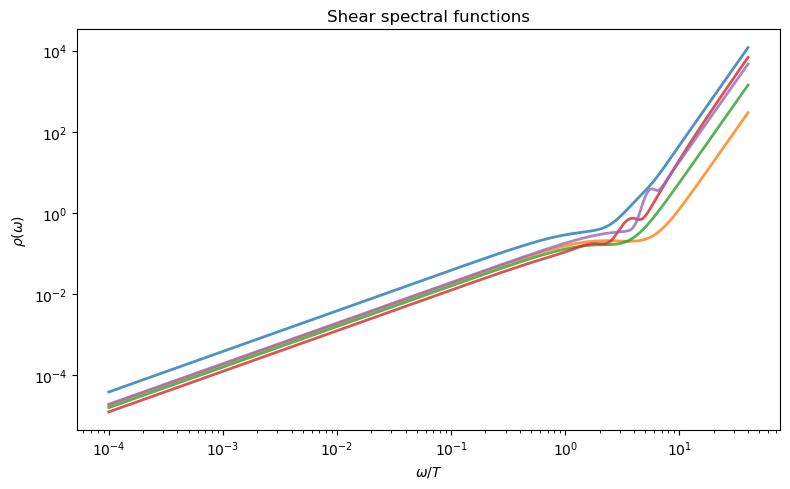

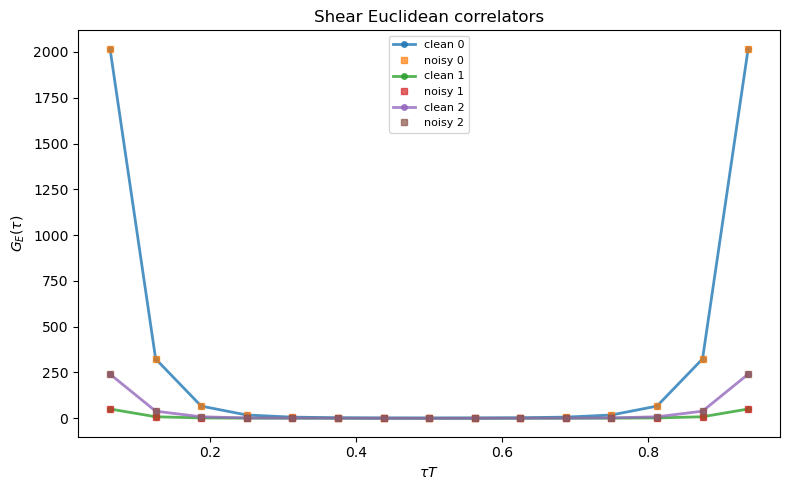

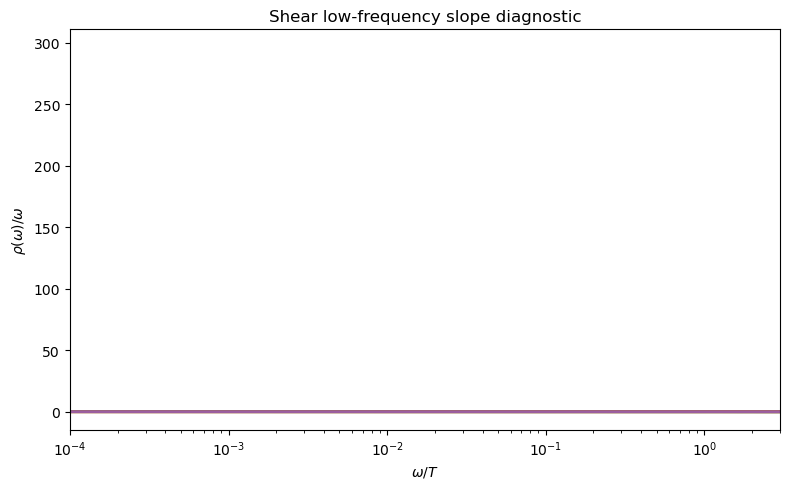

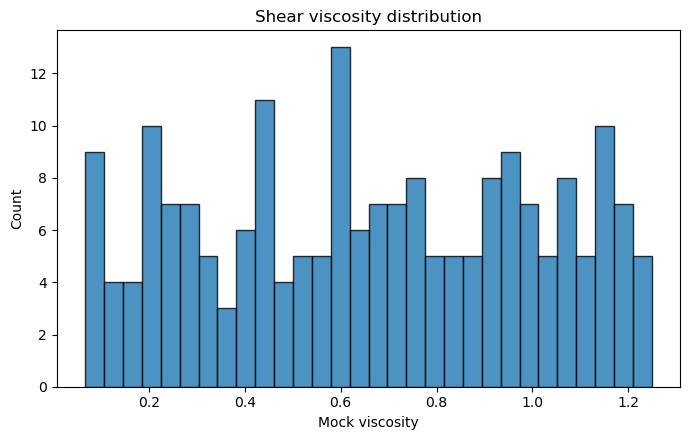

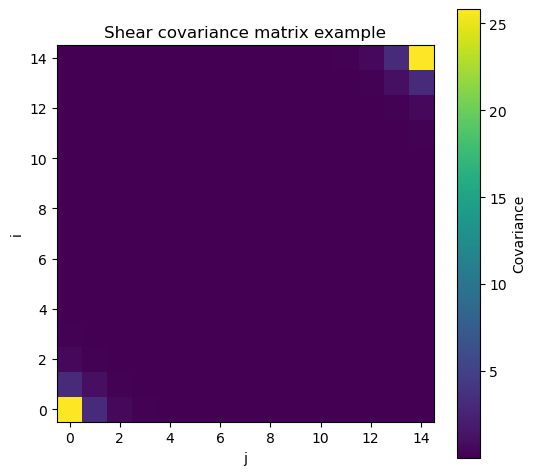

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import json
from dataclasses import dataclass


# ============================================================
# 1. USER SETTINGS
# ============================================================

CHANNEL = "shear"         # "shear" or "bulk"
NSAMPLES = 200
NTAU = 16
SEED = 1234
OUT_FILE = "mock_dataset.npz"

# Frequency grid
WMIN = 1e-4
WSPLIT = 1.0
WMAX = 40.0
NLOG = 200
NLIN = 400

# Noise model
REL_BASE = 0.002
REL_MID = 0.01
MID_WIDTH = 0.18
CORR_LENGTH = 2.0
CORRELATED = True

# Bulk-specific settings
BULK_TMIN = 0.85
BULK_TMAX = 1.35
BULK_TC = 1.0
BULK_PEAK_HEIGHT = 2.0
BULK_PEAK_WIDTH = 0.12


# ============================================================
# 2. GRID UTILITIES
# ============================================================

def make_frequency_grid(wmin=1e-4, wsplit=1.0, wmax=40.0, nlog=200, nlin=400):
    w_log = np.logspace(np.log10(wmin), np.log10(wsplit), nlog, endpoint=False)
    w_lin = np.linspace(wsplit, wmax, nlin)
    return np.unique(np.concatenate([w_log, w_lin]))


def make_tau_grid(Ntau=16, exclude_endpoints=True):
    if exclude_endpoints:
        return np.arange(1, Ntau) / Ntau
    else:
        return np.arange(0, Ntau + 1) / Ntau


def trapezoidal_weights(x):
    x = np.asarray(x)
    dx = np.diff(x)
    w = np.zeros_like(x)
    w[1:-1] = 0.5 * (dx[:-1] + dx[1:])
    w[0] = 0.5 * dx[0]
    w[-1] = 0.5 * dx[-1]
    return w


# ============================================================
# 3. SPECTRAL FUNCTION HELPERS
# ============================================================

def smooth_switch(w, Lambda=3.0, sharpness=4.0):
    x = (w / Lambda) ** sharpness
    return x / (1.0 + x)


def gaussian_bump(w, amp, mu, sigma, power=1):
    return amp * (w ** power) * np.exp(-0.5 * ((w - mu) / sigma) ** 2)


def lorentzian_transport_peak(w, A, Gamma):
    return A * w / (1.0 + (w / Gamma) ** 2)


@dataclass
class ShearParams:
    A: float
    Gamma: float
    B: float
    Lambda_uv: float
    sharpness_uv: float
    n_bumps: int
    bump_amps: np.ndarray
    bump_mus: np.ndarray
    bump_sigmas: np.ndarray


@dataclass
class BulkParams:
    A: float
    Gamma: float
    D: float
    Lambda_uv: float
    sharpness_uv: float
    n_bumps: int
    bump_amps: np.ndarray
    bump_mus: np.ndarray
    bump_sigmas: np.ndarray
    Tc: float
    T: float


def rho_shear(w, params):
    rho_ir = lorentzian_transport_peak(w, params.A, params.Gamma)
    rho_uv = params.B * (w ** 4) * smooth_switch(w, params.Lambda_uv, params.sharpness_uv)

    rho_mid = np.zeros_like(w)
    for amp, mu, sigma in zip(params.bump_amps, params.bump_mus, params.bump_sigmas):
        rho_mid += gaussian_bump(w, amp, mu, sigma, power=3)

    rho = rho_ir + rho_mid + rho_uv
    return np.maximum(rho, 0.0)


def bulk_peak_enhancement(T, Tc=1.0, height=2.0, width=0.12):
    return 1.0 + height * np.exp(-0.5 * ((T - Tc) / width) ** 2)


def rho_bulk(w, params, peak_height=2.0, peak_width=0.12):
    enh = bulk_peak_enhancement(params.T, params.Tc, peak_height, peak_width)
    A_eff = params.A * enh

    rho_ir = lorentzian_transport_peak(w, A_eff, params.Gamma)
    rho_uv = params.D * (w ** 4) * smooth_switch(w, params.Lambda_uv, params.sharpness_uv)

    rho_mid = np.zeros_like(w)
    for amp, mu, sigma in zip(params.bump_amps, params.bump_mus, params.bump_sigmas):
        rho_mid += gaussian_bump(w, amp, mu, sigma, power=1)

    rho = rho_ir + rho_mid + rho_uv
    return np.maximum(rho, 0.0)


def sample_shear_params(rng):
    A = rng.uniform(0.02, 0.4)
    Gamma = rng.uniform(0.2, 4.0)
    B = rng.uniform(1e-4, 5e-3)
    Lambda_uv = rng.uniform(2.0, 6.0)
    sharpness_uv = rng.uniform(2.0, 8.0)

    n_bumps = rng.integers(0, 3)
    if n_bumps > 0:
        bump_amps = rng.uniform(1e-3, 5e-2, size=n_bumps)
        bump_mus = rng.uniform(1.0, 8.0, size=n_bumps)
        bump_sigmas = rng.uniform(0.2, 1.5, size=n_bumps)
    else:
        bump_amps = np.array([])
        bump_mus = np.array([])
        bump_sigmas = np.array([])

    return ShearParams(A, Gamma, B, Lambda_uv, sharpness_uv,
                       n_bumps, bump_amps, bump_mus, bump_sigmas)


def sample_bulk_params(rng, T=1.0, Tc=1.0):
    A = rng.uniform(0.005, 0.2)
    Gamma = rng.uniform(0.1, 3.0)
    D = rng.uniform(5e-5, 5e-3)
    Lambda_uv = rng.uniform(2.0, 6.0)
    sharpness_uv = rng.uniform(2.0, 8.0)

    n_bumps = rng.integers(0, 3)
    if n_bumps > 0:
        bump_amps = rng.uniform(1e-3, 5e-2, size=n_bumps)
        bump_mus = rng.uniform(0.5, 6.0, size=n_bumps)
        bump_sigmas = rng.uniform(0.2, 1.2, size=n_bumps)
    else:
        bump_amps = np.array([])
        bump_mus = np.array([])
        bump_sigmas = np.array([])

    return BulkParams(A, Gamma, D, Lambda_uv, sharpness_uv,
                      n_bumps, bump_amps, bump_mus, bump_sigmas, Tc, T)


def generate_random_shear_spectrum(w, rng):
    params = sample_shear_params(rng)
    rho = rho_shear(w, params)
    return rho, params


def generate_random_bulk_spectrum(w, rng, T=1.0, Tc=1.0):
    params = sample_bulk_params(rng, T=T, Tc=Tc)
    rho = rho_bulk(w, params, peak_height=BULK_PEAK_HEIGHT, peak_width=BULK_PEAK_WIDTH)
    return rho, params


def mock_eta_from_params(params, prefactor=np.pi):
    return prefactor * params.A


def mock_zeta_from_params(params, prefactor=np.pi):
    enh = bulk_peak_enhancement(params.T, params.Tc, BULK_PEAK_HEIGHT, BULK_PEAK_WIDTH)
    return prefactor * params.A * enh


# ============================================================
# 4. EUCLIDEAN KERNEL AND CORRELATOR
# ============================================================

def thermal_kernel(u, w):
    u = np.atleast_1d(u)
    w = np.atleast_1d(w)

    U = u[:, None]
    W = w[None, :]

    small = W < 1e-8
    denom = 1.0 - np.exp(-W)
    K_generic = (np.exp(-W * U) + np.exp(-W * (1.0 - U))) / denom
    K_small = 2.0 / np.maximum(W, 1e-300)

    return np.where(small, K_small, K_generic)


def euclidean_correlator(w, rho, u, prefactor=1.0 / (2.0 * np.pi)):
    weights = trapezoidal_weights(w)
    K = thermal_kernel(u, w)
    G = prefactor * (K @ (rho * weights))
    return G


# ============================================================
# 5. NOISE MODEL
# ============================================================

@dataclass
class NoiseModel:
    rel_base: float = 0.002
    rel_mid: float = 0.01
    mid_width: float = 0.18
    corr_length: float = 2.0
    correlated: bool = True


def build_relative_error_profile(u, noise_model):
    return (
        noise_model.rel_base
        + noise_model.rel_mid * np.exp(-0.5 * ((u - 0.5) / noise_model.mid_width) ** 2)
    )


def build_covariance_matrix(G, u, noise_model):
    rel_err = build_relative_error_profile(u, noise_model)
    sigma = rel_err * np.maximum(np.abs(G), 1e-14)

    if not noise_model.correlated:
        return np.diag(sigma ** 2)

    idx = np.arange(len(u))
    dist = np.abs(idx[:, None] - idx[None, :])
    corr = np.exp(-dist / noise_model.corr_length)
    C = corr * np.outer(sigma, sigma)
    return C


def add_gaussian_noise(G, C, rng):
    jitter = 1e-14 * np.eye(len(G))
    L = np.linalg.cholesky(C + jitter)
    z = rng.normal(size=len(G))
    return G + L @ z


# ============================================================
# 6. DATASET GENERATION
# ============================================================

def to_python(obj):
    """
    Recursively convert numpy types to native Python types
    so they can be serialized with json.dumps().
    """
    if isinstance(obj, dict):
        return {str(k): to_python(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [to_python(x) for x in obj]
    elif isinstance(obj, np.ndarray):
        return [to_python(x) for x in obj.tolist()]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, (np.bool_,)):
        return bool(obj)
    else:
        return obj


def params_to_dict(params):
    return to_python(vars(params))


def generate_dataset(
    channel="shear",
    nsamples=100,
    Ntau=16,
    seed=1234
):
    rng = np.random.default_rng(seed)

    w = make_frequency_grid(WMIN, WSPLIT, WMAX, NLOG, NLIN)
    u = make_tau_grid(Ntau=Ntau, exclude_endpoints=True)

    noise_model = NoiseModel(
        rel_base=REL_BASE,
        rel_mid=REL_MID,
        mid_width=MID_WIDTH,
        corr_length=CORR_LENGTH,
        correlated=CORRELATED
    )

    rho_all = []
    G_clean_all = []
    G_noisy_all = []
    cov_all = []
    viscosity_all = []
    temperature_all = []
    params_list = []

    for i in range(nsamples):
        if channel == "shear":
            rho, params = generate_random_shear_spectrum(w, rng)
            viscosity = mock_eta_from_params(params)
            T_sample = 1.0

        elif channel == "bulk":
            T_sample = rng.uniform(BULK_TMIN, BULK_TMAX)
            rho, params = generate_random_bulk_spectrum(w, rng, T=T_sample, Tc=BULK_TC)
            viscosity = mock_zeta_from_params(params)

        else:
            raise ValueError("channel must be 'shear' or 'bulk'")

        G_clean = euclidean_correlator(w, rho, u)
        C = build_covariance_matrix(G_clean, u, noise_model)
        G_noisy = add_gaussian_noise(G_clean, C, rng)

        rho_all.append(rho)
        G_clean_all.append(G_clean)
        G_noisy_all.append(G_noisy)
        cov_all.append(C)
        viscosity_all.append(viscosity)
        temperature_all.append(T_sample)
        params_list.append(params_to_dict(params))

        if (i + 1) % max(1, nsamples // 10) == 0:
            print(f"Generated {i+1}/{nsamples}")

    metadata = to_python({
        "channel": channel,
        "nsamples": nsamples,
        "Ntau": Ntau,
        "seed": seed,
        "noise": {
            "rel_base": REL_BASE,
            "rel_mid": REL_MID,
            "mid_width": MID_WIDTH,
            "corr_length": CORR_LENGTH,
            "correlated": CORRELATED
        },
        "bulk_settings": {
            "Tmin": BULK_TMIN,
            "Tmax": BULK_TMAX,
            "Tc": BULK_TC,
            "peak_height": BULK_PEAK_HEIGHT,
            "peak_width": BULK_PEAK_WIDTH
        }
    })

    dataset = {
        "w": np.array(w),
        "u": np.array(u),
        "rho": np.array(rho_all),
        "G_clean": np.array(G_clean_all),
        "G_noisy": np.array(G_noisy_all),
        "cov": np.array(cov_all),
        "viscosity": np.array(viscosity_all),
        "temperature": np.array(temperature_all),
        "params_json": json.dumps(to_python(params_list)),
        "metadata_json": json.dumps(metadata)
    }

    return dataset


# ============================================================
# 7. RUN DATASET GENERATION
# ============================================================

dataset = generate_dataset(
    channel=CHANNEL,
    nsamples=NSAMPLES,
    Ntau=NTAU,
    seed=SEED
)

print("\nDataset generated.")
print("rho shape     :", dataset["rho"].shape)
print("G_clean shape :", dataset["G_clean"].shape)
print("G_noisy shape :", dataset["G_noisy"].shape)
print("cov shape     :", dataset["cov"].shape)


# ============================================================
# 8. SAVE DATASET
# ============================================================

np.savez_compressed(
    OUT_FILE,
    w=dataset["w"],
    u=dataset["u"],
    rho=dataset["rho"],
    G_clean=dataset["G_clean"],
    G_noisy=dataset["G_noisy"],
    cov=dataset["cov"],
    viscosity=dataset["viscosity"],
    temperature=dataset["temperature"],
    params_json=np.array(dataset["params_json"], dtype=object),
    metadata_json=np.array(dataset["metadata_json"], dtype=object),
)

print(f"\nSaved dataset to: {OUT_FILE}")


# ============================================================
# 9. QUICK PLOTS
# ============================================================

# Plot a few spectral functions
plt.figure(figsize=(8, 5))
for i in range(min(5, NSAMPLES)):
    plt.loglog(dataset["w"], dataset["rho"][i], lw=2, alpha=0.8)
plt.xlabel(r'$\omega/T$')
plt.ylabel(r'$\rho(\omega)$')
plt.title(f'{CHANNEL.capitalize()} spectral functions')
plt.tight_layout()
plt.show()

# Plot a few clean and noisy correlators
plt.figure(figsize=(8, 5))
for i in range(min(3, NSAMPLES)):
    plt.plot(dataset["u"], dataset["G_clean"][i], '-o', lw=2, ms=4, alpha=0.8, label=f'clean {i}')
    plt.plot(dataset["u"], dataset["G_noisy"][i], 's', ms=4, alpha=0.7, label=f'noisy {i}')
plt.xlabel(r'$\tau T$')
plt.ylabel(r'$G_E(\tau)$')
plt.title(f'{CHANNEL.capitalize()} Euclidean correlators')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Plot rho(omega)/omega for a few samples to inspect low-frequency slope
plt.figure(figsize=(8, 5))
for i in range(min(5, NSAMPLES)):
    plt.semilogx(
        dataset["w"],
        dataset["rho"][i] / np.maximum(dataset["w"], 1e-12),
        lw=2,
        alpha=0.8
    )
plt.xlim(1e-4, 3)
plt.xlabel(r'$\omega/T$')
plt.ylabel(r'$\rho(\omega)/\omega$')
plt.title(f'{CHANNEL.capitalize()} low-frequency slope diagnostic')
plt.tight_layout()
plt.show()

# Plot viscosity histogram
plt.figure(figsize=(7, 4.5))
plt.hist(dataset["viscosity"], bins=30, alpha=0.8, edgecolor='black')
plt.xlabel('Mock viscosity')
plt.ylabel('Count')
plt.title(f'{CHANNEL.capitalize()} viscosity distribution')
plt.tight_layout()
plt.show()

# Show one covariance matrix example
plt.figure(figsize=(5.5, 5))
plt.imshow(dataset["cov"][0], origin='lower', cmap='viridis')
plt.colorbar(label='Covariance')
plt.xlabel('j')
plt.ylabel('i')
plt.title(f'{CHANNEL.capitalize()} covariance matrix example')
plt.tight_layout()
plt.show()